<a href="https://colab.research.google.com/github/5ANDAR8H-5INGH/DOCTOR_PRESCRIPTION_ANALYZER/blob/main/Prescription_analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
medicine_dict = pd.read_csv('druglist.csv')
medicine_dict.head()

,drug
0,a-to-z-woman-cap-15-s-174701
1,ab-phylline-100mg-strip-of-10-capsules-25470
2,ab-phylline-sr-200mg-tablet-25579
3,absolut-woman-cap-22096
4,absolut-3g-cap-32672


In [ ]:
medicine_dict.isnull().sum()

drug    0
dtype: int64

In [ ]:
medicine_dict.duplicated().sum()

0

Data Cleaning

In [ ]:
# !pip install ftfy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00


In [ ]:
# import ftfy
# medicine_dict['drug'] = medicine_dict['drug'].apply(lambda x : ftfy.fix_text(x))

In [ ]:
# medicine_dict['drug'] = medicine_dict['drug'].apply(lambda x : x.replace('-', ' '))
# display(medicine_dict.head())

,drug
0,a to z woman cap 15 s 174701
1,ab phylline 100mg strip of 10 capsules 25470
2,ab phylline sr 200mg tablet 25579
3,absolut woman cap 22096
4,absolut 3g cap 32672


In [ ]:
# import re
# medicine_dict['drug'] = medicine_dict['drug'].apply(lambda x: re.sub(r'\s+\d+$', '', str(x)))
# # This pattern looks for:
# # \s+ (whitespace before the number)
# # \d+ (one or more digits)
# # $   (at the very end of the string)

In [ ]:
# medicine_dict['drug'] = medicine_dict['drug'].apply(lambda x: str(x).lower())

In [ ]:
import re

# # Define the list of form words and units to remove
# # \d+[mgiu]+ matches numbers followed by mg, g, iu, etc.
# # The list of words covers cap, capsule, tablet, tab, strip, etc.
# # \bsr\b targets the 'sr' (sustained release) variant specifically
# patterns_to_remove = [
#     r'\d+\s?[mgiu]+',          # Dosages: 100mg, 3mg, 100iu
#     r'\bstrip\b',              # Form: strip
#     r'\bof\b',                 # Connector: of
#     r'\b\d+\b',                # Standalone numbers: 10, 30, 20
#     r'\bcap(sules?)?\b',       # Form: cap, capsule, capsules
#     r'\btab(lets?)?\b',        # Form: tab, tablet, tablets
#     r'\bsr\b',                 # Variant: sr
#     r'\b-s\b'                  # Trailing single 's'
# ]

# # Combine into one regex pattern
# combined_pattern = '|'.join(patterns_to_remove)

# # Apply the cleaning
# # 1. Remove the patterns
# # 2. Convert to lower (if not already done)
# # 3. Strip extra whitespace left behind
# medicine_dict['drug'] = (medicine_dict['drug']
#                          .str.replace(combined_pattern, '', regex=True)
#                          .str.lower()
#                          .str.replace(r'\s+', ' ', regex=True) # Collapse multiple spaces
#                          .str.strip())                         # Remove leading/trailing spaces


In [ ]:
# medicine_dict[medicine_dict['drug'] == 'paracetamol'].index

Index([163902], dtype='int64')

In [ ]:
# medicine_dict['drug'] = medicine_dict['drug'].str.replace(r'\b[mds]\b', '', regex=True)

# medicine_dict['drug'] = medicine_dict['drug'].str.replace(r'\s+', ' ', regex=True).str.strip()


In [ ]:
# # Remove empty
# medicine_dict = medicine_dict[medicine_dict['drug'] != ""]

# # Remove short tokens
# medicine_dict = medicine_dict[medicine_dict['drug'].str.len() > 4]

# # Remove common English words
# common_words = [
#     "after", "before", "daily", "days", "night",
#     "morning", "evening", "meals", "meal",
#     "solution", "injection", "tablet", "capsule"
# ]

# medicine_dict = medicine_dict[~medicine_dict['drug'].isin(common_words)]

# medicine_dict = medicine_dict.drop_duplicates().reset_index(drop=True)

# medicine_dict.head()

,drug
0,a to z woman
1,ab phylline
2,absolut woman
3,absolut
4,acitrom


In [ ]:
# medicine_dict.to_csv("medicine_dict.csv", index=False)

In [ ]:
# df_2 = pd.read_csv("prescription_text.csv")
# print(df_2.head())

                              prescription_text label
0   Tab Paracetamol 500mg BD after meals 3 days    DO
1  Tab Paracetamol 650mg TDS after meals 3 days    DO
2           Tab Paracetamol 500mg SOS for fever    DO
3               Tab Brufen 400mg BD after meals    DO
4              Tab Brufen 600mg TDS after meals    DO


In [ ]:
map = {
    r"\bOD\b": "once daily",
    r"\bBD\b": "twice daily",
    r"\bTDS\b": "three times daily",
    r"\bSOS\b": "when needed",
    r"\bHS\b": "at bedtime"
}

In [ ]:
def clean_text(text):
    text = str(text).lower()
    for abbr, full_form in map.items():
        text = re.sub(abbr.lower(), full_form, text)
        text = re.sub(r"[^a-z0-9\s]", " ", text)
        text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
# df_2["clean_text"] = df_2["prescription_text"].apply(clean_text)
# print(df_2.head())

                              prescription_text label  \
0   Tab Paracetamol 500mg BD after meals 3 days    DO   
1  Tab Paracetamol 650mg TDS after meals 3 days    DO   
2           Tab Paracetamol 500mg SOS for fever    DO   
3               Tab Brufen 400mg BD after meals    DO   
4              Tab Brufen 600mg TDS after meals    DO   

                                          clean_text  
0  tab paracetamol 500mg twice daily after meals ...  
1  tab paracetamol 650mg three times daily after ...  
2        tab paracetamol 500mg when needed for fever  
3           tab brufen 400mg twice daily after meals  
4     tab brufen 600mg three times daily after meals  


In [ ]:
# df_2.to_csv("prescription_text_cleaned.csv", index=False)

In [ ]:
# df = pd.read_csv("prescription_text_cleaned.csv")

In [ ]:
dosage_pattern = r"\b\d+\s?(?:mg|ml|g|tablet|tab|capsule|cap)\b"
frequency_pattern = r"\b(once daily|twice daily|three times daily|when needed)\b"
timing_pattern = r"\b(after meals?|before meals?|before breakfast|after breakfast|at night|at bedtime|during fever)\b"
duration_pattern = r"\b\d+\s?days?\b"

In [ ]:
def extract_information(text):
    info = {}

    info["dosage"] = re.findall(dosage_pattern, text)
    info["frequency"] = re.findall(frequency_pattern, text)
    info["timing"] = re.findall(timing_pattern, text)
    info["duration"] = re.findall(duration_pattern, text)

    return info

In [ ]:
# df["extracted_info"] = df["clean_text"].apply(extract_information)

# print(df[["clean_text", "extracted_info"]].head())

                                          clean_text  \
0  tab paracetamol 500mg twice daily after meals ...   
1  tab paracetamol 650mg three times daily after ...   
2        tab paracetamol 500mg when needed for fever   
3           tab brufen 400mg twice daily after meals   
4     tab brufen 600mg three times daily after meals   

                                      extracted_info  
0  {'dosage': ['500mg'], 'frequency': ['twice dai...  
1  {'dosage': ['650mg'], 'frequency': ['three tim...  
2  {'dosage': ['500mg'], 'frequency': ['when need...  
3  {'dosage': ['400mg'], 'frequency': ['twice dai...  
4  {'dosage': ['600mg'], 'frequency': ['three tim...  


In [ ]:
medicine_dict = pd.read_csv("medicine_dict.csv")

In [ ]:
medicine_list = medicine_dict["drug"].tolist()

In [ ]:
def extract_medicine(text):
    found = []
    for med in medicine_list:
        pattern = r"\b" + re.escape(med) + r"\b"
        if re.search(pattern, text):
            found.append(med)
    return found

In [ ]:
# df['medicine_name'] = df['clean_text'].apply(extract_medicine)

In [ ]:
# df.head()

,prescription_text,label,clean_text,extracted_info,medicine_name
0,Tab Paracetamol 500mg BD after meals 3 days,DO,tab paracetamol 500mg twice daily after meals ...,"{'dosage': ['500mg'], 'frequency': ['twice dai...",[paracetamol]
1,Tab Paracetamol 650mg TDS after meals 3 days,DO,tab paracetamol 650mg three times daily after ...,"{'dosage': ['650mg'], 'frequency': ['three tim...",[paracetamol]
2,Tab Paracetamol 500mg SOS for fever,DO,tab paracetamol 500mg when needed for fever,"{'dosage': ['500mg'], 'frequency': ['when need...",[paracetamol]
3,Tab Brufen 400mg BD after meals,DO,tab brufen 400mg twice daily after meals,"{'dosage': ['400mg'], 'frequency': ['twice dai...",[brufen]
4,Tab Brufen 600mg TDS after meals,DO,tab brufen 600mg three times daily after meals,"{'dosage': ['600mg'], 'frequency': ['three tim...",[brufen]


In [ ]:
# df.to_csv("prescription_final.csv", index=False)

In [ ]:
df = pd.read_csv("prescription_final.csv")

In [ ]:
df['extracted_info'].iloc[0]

"{'dosage': ['500mg'], 'frequency': ['twice daily'], 'timing': ['after meals'], 'duration': ['3 days']}"

In [ ]:
df['medicine_name'].iloc[0]

"['paracetamol']"

In [ ]:
df = pd.read_csv("prescription_text_cleaned.csv")
print(df.head())

                              prescription_text label  \
0   Tab Paracetamol 500mg BD after meals 3 days    DO   
1  Tab Paracetamol 650mg TDS after meals 3 days    DO   
2           Tab Paracetamol 500mg SOS for fever    DO   
3               Tab Brufen 400mg BD after meals    DO   
4              Tab Brufen 600mg TDS after meals    DO   

                                          clean_text  
0  tab paracetamol 500mg twice daily after meals ...  
1  tab paracetamol 650mg three times daily after ...  
2        tab paracetamol 500mg when needed for fever  
3           tab brufen 400mg twice daily after meals  
4     tab brufen 600mg three times daily after meals  


In [ ]:
X = df["clean_text"]
y = df["label"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=3000
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

all_models={
    "Naive Bayes":MultinomialNB(),
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "SVM":LinearSVC(),
    "Random Forest":RandomForestClassifier(),
    "Gradient Boosting":GradientBoostingClassifier()}

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results=[]
for name, model_instance in all_models.items():
  model_instance.fit(X_train_vec,y_train)
  y_pred=model_instance.predict(X_test_vec)
  accuracy=accuracy_score(y_test,y_pred)
  precision=precision_score(y_test,y_pred, average='weighted')
  recall=recall_score(y_test,y_pred, average='weighted')
  f1=f1_score(y_test,y_pred, average='weighted')
  results.append([name,accuracy,precision,recall,f1])

c:\Users\sanda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sanda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sanda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sanda\anaconda3\Lib\site-packag

In [ ]:
results_df=pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1 Score'])
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.642857,0.466518,0.642857,0.534392
1,Logistic Regression,0.642857,0.466518,0.642857,0.534392
2,SVM,0.607143,0.546429,0.607143,0.561224
3,Random Forest,0.642857,0.639881,0.642857,0.633644
4,Gradient Boosting,0.500000,0.486735,0.500000,0.487310


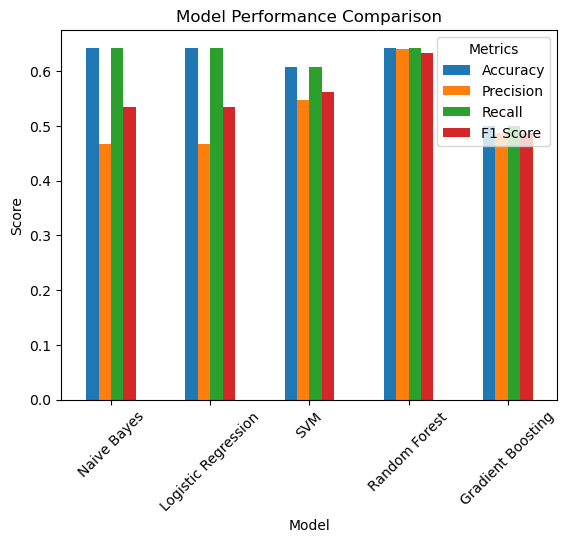

In [ ]:
import matplotlib.pyplot as plt
results_df.set_index('Model')[['Accuracy','Precision','Recall','F1 Score']].plot(kind="bar")
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title='Metrics')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_vec, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report, accuracy_score
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6428571428571429
                        precision    recall  f1-score   support

                    DO       0.89      0.73      0.80        11
                  DONT       0.50      1.00      0.67         3
               WARNING       0.56      0.83      0.67         6
        dietary_advice       0.50      0.50      0.50         2
             follow_up       0.00      0.00      0.00         1
      lifestyle_advice       0.00      0.00      0.00         2
medication_instruction       1.00      0.50      0.67         2
               warning       0.00      0.00      0.00         1

              accuracy                           0.64        28
             macro avg       0.43      0.45      0.41        28
          weighted avg       0.63      0.64      0.61        28



c:\Users\sanda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sanda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sanda\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# import joblib
# joblib.dump(model, "prescription_model.pkl")
# joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['prescription_model.pkl']

In [ ]:
def classify_instruction(text):
    cleaned = clean_text(text)
    vector = vectorizer.transform([cleaned])
    prediction = model.predict(vector)
    return prediction[0]

In [ ]:
classify_instruction("Take 1 tablet of paracetamol 500mg after meals for 5 days")

'medication_instruction'

In [ ]:
!pip install pytesseract pillow opencv-python

In [ ]:
import pytesseract
from PIL import Image

def extract_text_from_image(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text

In [ ]:
# text = extract_text_from_image("sample.jpg")
# print(text)

In [ ]:
def analyze_prescription_image(path):

    text = extract_text_from_image(path)

    cleaned = clean_text(text)

    info = extract_information(cleaned)
    medicines = extract_medicine(cleaned)

    instruction = classify_instruction(cleaned)

    result = {
        "medicine_name": medicines,
        "dosage": info["dosage"],
        "frequency": info["frequency"],
        "timing": info["timing"],
        "duration": info["duration"],
        "instruction": instruction
    }

    return result

In [ ]:
result = analyze_prescription_image("prescription_6.jpg")

result

{'medicine_name': ['paracetamol'],
 'dosage': ['650mg'],
 'frequency': ['when needed', 'once daily'],
 'timing': [],
 'duration': [],
 'instruction': 'DO'}